Epoch 1 - Train Loss: 0.4500, Train Acc: 52.50% | Val Loss: 0.3280, Val Acc: 50.00%
Epoch 2 - Train Loss: 0.0372, Train Acc: 95.00% | Val Loss: 0.2464, Val Acc: 50.00%
Epoch 3 - Train Loss: 0.0242, Train Acc: 97.50% | Val Loss: 0.1752, Val Acc: 50.00%
Epoch 4 - Train Loss: 0.0173, Train Acc: 97.50% | Val Loss: 0.1189, Val Acc: 85.00%
Epoch 5 - Train Loss: 0.0127, Train Acc: 98.75% | Val Loss: 0.0813, Val Acc: 100.00%


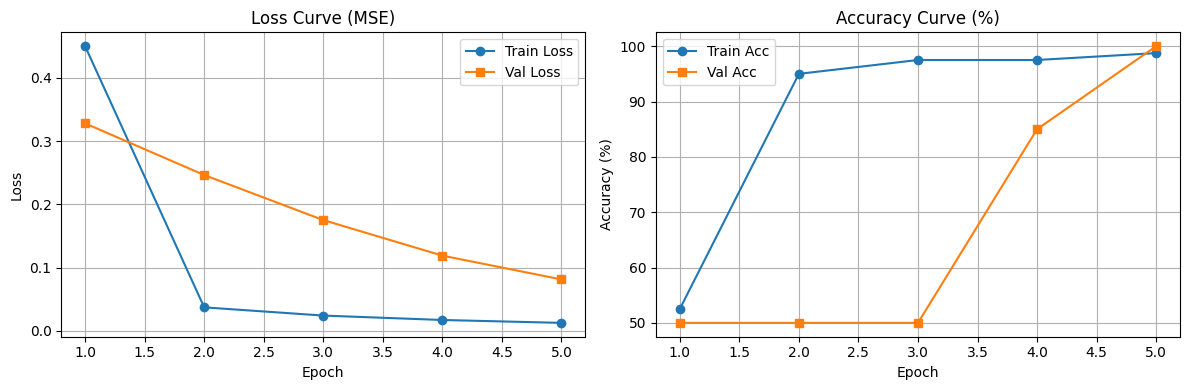

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load Iris dataset (Setosa & Versicolor only)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=['x1', 'x2', 'x3', 'x4'])
df['target'] = iris.target
df = df[df['target'] < 2].reset_index(drop=True)

# Train-validation split (80:20)
df_train = pd.concat([df.iloc[0:40], df.iloc[50:90]]).reset_index(drop=True)
df_val = pd.concat([df.iloc[40:50], df.iloc[90:100]]).reset_index(drop=True)

# Hyperparameters and initial weights
lr, epochs = 0.1, 5
bias = 0.5
w = np.full(4, 0.5)

train_loss_hist, train_acc_hist = [], []
val_loss_hist, val_acc_hist = [], []

# Training & validation loop
for epoch in range(epochs):
    # Training phase (Online SGD)
    train_sse, train_correct = 0, 0
    for i in range(len(df_train)):
        x = df_train.iloc[i, :4].values
        target = df_train.iloc[i]['target']

        z = bias + np.dot(x, w)
        gz = 1.0 / (1.0 + np.exp(-z))

        pred = 1 if gz >= 0.5 else 0
        if pred == target:
            train_correct += 1

        error = gz - target
        train_sse += error**2

        dbias = 2 * error * gz * (1 - gz)
        bias -= lr * dbias
        w -= lr * dbias * x

    train_loss = train_sse / len(df_train)
    train_acc = (train_correct / len(df_train)) * 100
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # Validation phase
    val_sse, val_correct = 0, 0
    for i in range(len(df_val)):
        x = df_val.iloc[i, :4].values
        target = df_val.iloc[i]['target']

        z = bias + np.dot(x, w)
        gz = 1.0 / (1.0 + np.exp(-z))
        pred = 1 if gz >= 0.5 else 0

        if pred == target:
            val_correct += 1
        val_sse += (gz - target) ** 2

    val_loss = val_sse / len(df_val)
    val_acc = (val_correct / len(df_val)) * 100
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f'Epoch {epoch+1} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

# Plot evaluation metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_loss_hist, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_loss_hist, label='Val Loss', marker='s')
plt.title('Loss Curve (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_acc_hist, label='Train Acc', marker='o')
plt.plot(range(1, epochs + 1), val_acc_hist, label='Val Acc', marker='s')
plt.title('Accuracy Curve (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()